In [1]:
import pandas as pd
import numpy as np

In [2]:
from openai import OpenAI

In [12]:
from openai import OpenAI
import json

client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required",
)

# model = "qwen3.5-397b-a17b"
model = "qwen3.5-397b-a17b"

response = client.chat.completions.create(
    model=model,
    messages=[
        {
            "role": "system",
            "content": "Return only valid JSON. No markdown. No extra text."
        },
        {
            "role": "user",
            "content": 'Return JSON with fields: score integer 0..2, explanation string.'
        }
    ],
    temperature=0,
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "judge_score",
            "schema": {
                "type": "object",
                "properties": {
                    "score": {
                        "type": "integer",
                        "enum": [0, 1, 2]
                    },
                    "explanation": {
                        "type": "string"
                    }
                },
                "required": ["score", "explanation"],
                "additionalProperties": False
            }
        }
    }
)

content = response.choices[0].message.content
print(content)

parsed = json.loads(content)
parsed

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [8]:
print(repr(content))
print(content)

''



In [9]:
client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required"
)

In [ ]:
response = client.chat.completions.create(
    model="qwen/qwen3.5-35b-a3b",
    messages=[
        {"role": "user", "content": "Привет! Напиши одно короткое приветствие."}
    ]
)

In [21]:
print(response.choices[0].message.content)



Привет! 👋 Я — **Qwen3.5**, последняя версия большой языковой модели от Tongyi Lab. 

Я оптимизирован для эффективной работы: моя архитектура позволяет быстро обрабатывать сложные запросы, будь то анализ документов, генерация кода или креативные задачи. Хотя я не раскрываю точные технические детали (например, количество параметров), я спроектирован так, чтобы балансировать между мощью и скоростью — это значит, что вы получаете качественные результаты без лишних задержек. 

Чем могу помочь? 😊


In [7]:
df_RAG_questions = pd.read_csv(
    "AI_chat_bot_answers_all.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [8]:
# Сохраняем в Excel
df_RAG_questions.to_excel("AI_chat_bot_answers_all_20260623.xlsx", 
                    index=False,
                    engine='openpyxl')

In [7]:
df_RAG_questions = pd.read_csv(
    "AI_chat_bot_answers_ragas_test.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [9]:
df_RAG_questions.head(1)

,id,domain,source_type,source_id,source_url,question_type,difficulty,question,context,expected_answer,...,manual_final_score,manual_comment,model,temperature,latency_sec,created_at,prompt_tokens,completion_tokens,total_tokens,error
0,rag_question_001,Детский мир,sapiense,NaN,NaN,NaN,NaN,Как загрузить табеля вручную?,NaN,"Для ручной выгрузки табелей самозанятых, нужно...",...,NaN,NaN,NaN,NaN,24.793,2026-06-22T11:28:52,NaN,NaN,NaN,NaN


In [10]:
df_RAG_questions.to_excel("AI_chat_bot_answers_ragas_test.xlsx", 
                    index=False,
                    engine='openpyxl')

### Оценка ragas

In [9]:
df_ragas = pd.read_csv(
    "Ragas_answers_all_AI_chat_bot.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [10]:
df_ragas.to_excel("ragas_metrics.xlsx", 
                    index=False,
                    engine='openpyxl')

In [11]:
df_ragas_summary = pd.read_csv(
    "summary_data\\ragas_final_table.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [13]:
df_ragas_summary.head(2)

,id,domain,source_type,question,expected_answer,model_answer,ragas_factual_correctness,ragas_semantic_similarity,ragas_final_score,manual_final_score,latency_sec
0,rag_question_001,Детский мир,sapiense,Как загрузить табеля вручную?,"Для ручной выгрузки табелей самозанятых, нужно...",## Ручная загрузка табелей\n\nСогласно инструк...,"0,43","0,4858",2,2,"24,793"
1,rag_question_002,Детский мир,sapiense,Как обновить ранее загруженные данные по табел...,При загрузке табелей происходит полная перезап...,## Обновление ранее загруженных данных по табе...,"0,59","0,882",2,2,"24,509"


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

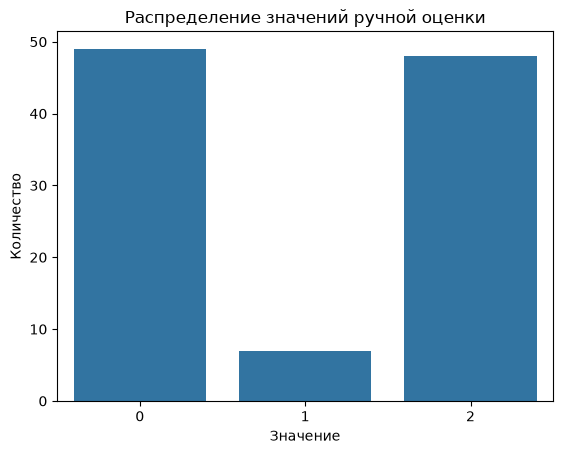

In [22]:
sns.countplot(
    data=df_ragas_summary,
    x="manual_final_score",
    order=[0, 1, 2]
)

plt.xlabel("Значение")
plt.ylabel("Количество")
plt.title("Распределение значений ручной оценки")
plt.show()

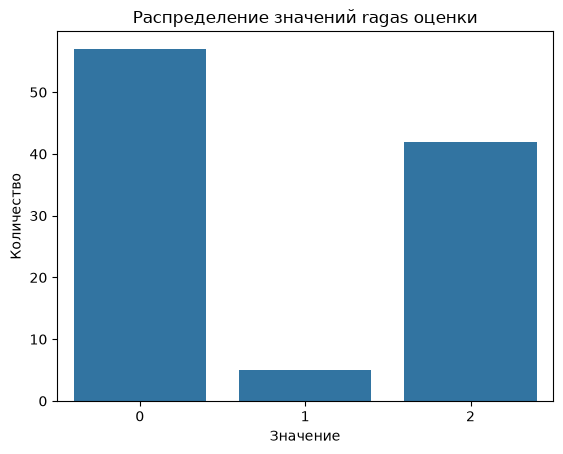

In [24]:
sns.countplot(
    data=df_ragas_summary,
    x="ragas_final_score",
    order=[0, 1, 2]
)

plt.xlabel("Значение")
plt.ylabel("Количество")
plt.title("Распределение значений ragas оценки")
plt.show()

In [17]:
df_ragas_summary.manual_final_score.mean()

np.float64(0.9903846153846154)

In [18]:
df_ragas_summary.ragas_final_score.mean()

np.float64(0.8557692307692307)

In [21]:
df_ragas_summary.dtypes

id                             str
domain                         str
source_type                    str
question                       str
expected_answer                str
model_answer                   str
ragas_factual_correctness      str
ragas_semantic_similarity      str
ragas_final_score            int64
manual_final_score           int64
latency_sec                    str
dtype: object

In [4]:
def convert_to_xlsx(df, output_file):
    df.to_excel(output_file, index=False, engine='openpyxl')

### Проверка несоотвевий judge 

In [3]:
df_not_match = pd.read_csv(
    "not_matching_scores.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [5]:
df_not_match_with_ans = pd.read_csv(
    "not_matching_scores_chatbot_answers.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [7]:
convert_to_xlsx(df_not_match_with_ans, "not_matching_scores_chatbot_answers.xlsx")

In [8]:
df_not_match_with_ans = pd.read_csv(
    "gemma_not_matching_scores_chatbot_answers_scored.csv",
    encoding="utf-8-sig",
    sep=";"
)
convert_to_xlsx(df_not_match_with_ans, "gemma_not_matching_scores_chatbot_answers_scored.xlsx")

In [9]:
df_not_match_with_ans = pd.read_csv(
    "qwen397b_not_matching_scores_chatbot_answers_scored.csv",
    encoding="utf-8-sig",
    sep=";"
)
convert_to_xlsx(df_not_match_with_ans, "qwen397b_not_matching_scores_chatbot_answers_scored.xlsx")

### Проверка qwen as a judge

In [13]:
df_qwen_check = pd.read_csv(
    "data\\forqwen_judge_scored_qwen397b.csv",
    encoding="utf-8-sig",
    sep=";"
)
convert_to_xlsx(df_qwen_check, "data\\forqwen_judge_scored_qwen397b.xlsx")

In [3]:
from typing import Literal
from pydantic import BaseModel, Field
from openai import OpenAI
import instructor

In [ ]:
class AnswerEvaluation(BaseModel):
    reasoning: str = Field(
        description="Короткое объяснение оценки на русском языке."
    )
    score: Literal[0, 1, 2] = Field(
        description="2 - полностью правильно, 1 - частично правильно, 0 - неправильно."
    )


base_client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required",
)

client = instructor.from_openai(
    base_client,
    mode=instructor.Mode.JSON_SCHEMA,
)

result = client.chat.completions.create(
    model="gemma-4-31b-it-mlx",
    response_model=AnswerEvaluation,
    messages=[
        {
            "role": "system",
            "content": "Ты строгий оценщик. Отвечай строго по заданной структуре."
        },
        {
            "role": "user",
            "content": """
Оцени ответ.

Вопрос:
Какие хранилища используют в аналитической системе Комус?

Эталон:
Используются ХД и SAP BW. Проблема в синхронизации загрузки данных из ХД в SAP BW.

Ответ модели:
Используются Oracle и ArenadataDB. Проблемы были с производительностью Oracle.

Верни оценку.
"""
        }
    ],
    temperature=0,
    max_tokens=5000,
)

print(result.score)
print(result.reasoning)

reasoning='Ответ модели полностью противоречит эталону. Вместо указанных ХД и SAP BW модель называет Oracle и ArenadataDB, а также указывает иную проблему (производительность вместо синхронизации).' score=0
<class '__main__.AnswerEvaluation'>
0
Ответ модели полностью противоречит эталону. Вместо указанных ХД и SAP BW модель называет Oracle и ArenadataDB, а также указывает иную проблему (производительность вместо синхронизации).


In [5]:
print(result.score)
print(result.reasoning)

0
Ответ модели полностью противоречит эталону. Вместо указанных ХД и SAP BW модель называет Oracle и ArenadataDB, а также указывает иную проблему (производительность вместо синхронизации).


In [1]:
import requests
import json

url = "http://192.168.15.182:1234/v1/chat/completions"

headers = {
    "Content-Type": "application/json",
    "Authorization": "Bearer sk-no-key-required",
}

payload = {
    "model": "qwen3.5-397b-a17b",
    "messages": [
        {
            "role": "system",
            "content": "Ты отвечаешь кратко и по-русски."
        },
        {
            "role": "user",
            "content": "Объясни, что такое бинарное дерево поиска."
        }
    ],
    "temperature": 0,
    "max_tokens": 1024,
}

response = requests.post(
    url,
    headers=headers,
    json=payload,
    timeout=300,
)

In [8]:
import requests
import json

url = "http://192.168.15.182:1234/v1/chat/completions"

headers = {
    "Content-Type": "application/json",
    "Authorization": "Bearer sk-no-key-required",
}

question = "Что такое бинарное дерево поиска?"
expected_answer = """
Бинарное дерево поиска — это структура данных, где у каждого узла не больше двух потомков.
Для каждого узла значения в левом поддереве меньше значения узла, а значения в правом поддереве больше.
Это позволяет эффективно искать, вставлять и удалять элементы.
"""

model_answer = """
Бинарное дерево поиска — это дерево, где каждый узел может иметь двух детей.
Левый ребенок обычно меньше родителя, правый больше. Такая структура помогает быстрее искать данные.
"""

payload = {
    "model": "gemma-4-31b-it-mlx",
    "messages": [
        {
            "role": "system",
            "content": (
                "Ты строгий judge для оценки ответов. "
                "Верни только JSON без markdown, без ```json, без дополнительного текста."
            ),
        },
        {
            "role": "user",
            "content": f"""
Сравни ответ модели с эталонным ответом.

Вопрос:
{question}

Эталонный ответ:
{expected_answer}

Ответ модели:
{model_answer}

Верни JSON строго в таком формате:
{{
  "score": 2,
  "explanation": "Короткое объяснение на русском языке"
}}

Шкала:
2 - ответ полностью правильный
1 - ответ частично правильный
0 - ответ неправильный
""",
        },
    ],
    "temperature": 0,
    "max_tokens": 5000,
}

response = requests.post(
    url,
    headers=headers,
    json=payload,
    timeout=300,
)

print("HTTP status:", response.status_code)

data = response.json()
raw_content = data["choices"][0]["message"]["content"]

print("=== RAW MODEL CONTENT ===")
print(raw_content)

HTTP status: 200
=== RAW MODEL CONTENT ===
{
  "score": 2,
  "explanation": "Ответ модели верно передает все ключевые аспекты определения бинарного дерева поиска: ограничение по количеству потомков, правило расположения элементов и цель структуры."
}


In [7]:
print(data)

{'id': 'chatcmpl-9ry0yjvanre9i849asl5p', 'object': 'chat.completion', 'created': 1782891545, 'model': 'qwen3.5-397b-a17b', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '\n\n{\n  "score": 1,\n  "explanation": "Ответ передает общую суть, но содержит технические неточности: свойство BST должно выполняться всегда, а не «обычно», и относится ко всему поддереву, а не только к непосредственным детям."\n}', 'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Role: Strict judge.\n    *   Task: Compare model answer with reference (etalon) answer.\n    *   Input: Question, Etalon Answer, Model Answer.\n    *   Output Format: JSON only (no markdown, no ```json, no extra text).\n    *   Output Structure: `{"score": int, "explanation": "string"}`.\n    *   Scoring Scale: 2 (fully correct), 1 (partially correct), 0 (incorrect).\n    *   Language: Russian.\n\n2.  **Analyze the Content:**\n    *   **Question:** "Что такое бинарное дерево поиска?" (Wh

In [9]:
print(data)

{'id': 'chatcmpl-yfc35ty07nlgyahfgfte', 'object': 'chat.completion', 'created': 1782892063, 'model': 'gemma-4-31b-it-mlx', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '{\n  "score": 2,\n  "explanation": "Ответ модели верно передает все ключевые аспекты определения бинарного дерева поиска: ограничение по количеству потомков, правило расположения элементов и цель структуры."\n}', 'reasoning_content': '', 'tool_calls': []}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'prompt_tokens': 241, 'completion_tokens': 52, 'total_tokens': 293, 'completion_tokens_details': {'reasoning_tokens': 0}}, 'stats': {}, 'system_fingerprint': 'gemma-4-31b-it-mlx'}


In [1]:
from openai import OpenAI
import json

client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required",
    timeout=300,
)

question = "Что такое бинарное дерево поиска?"

expected_answer = """
Бинарное дерево поиска — это структура данных, где у каждого узла не больше двух потомков.
Для каждого узла значения в левом поддереве меньше значения узла, а значения в правом поддереве больше.
Это свойство выполняется для всего поддерева, а не только для непосредственных детей.
"""

model_answer = """
Бинарное дерево поиска — это дерево, где каждый узел может иметь двух детей.
Левый ребенок обычно меньше родителя, правый больше. Такая структура помогает быстрее искать данные.
"""

response = client.chat.completions.create(
    model="qwen3.5-397b-a17b",
    messages=[
        {
            "role": "system",
            "content": (
                "Ты строгий оценщик ответов. "
                "Верни только валидный JSON без markdown и без текста вне JSON. "
                "Поле explanation всегда пиши на русском языке."
            ),
        },
        {
            "role": "user",
            "content": f"""
Оцени ответ модели по шкале 0/1/2.

Шкала:
2 - ответ полностью правильный
1 - ответ частично правильный
0 - ответ неправильный

Вопрос:
{question}

Эталонный ответ:
{expected_answer}

Ответ модели:
{model_answer}
""",
        },
    ],
    temperature=0,
    max_tokens=5000,
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "judge_score",
            "schema": {
                "type": "object",
                "properties": {
                    "score": {
                        "type": "integer",
                        "enum": [0, 1, 2],
                    },
                    "explanation": {
                        "type": "string",
                    },
                },
                "required": ["score", "explanation"],
                "additionalProperties": False,
            },
        },
    },
)

print("=== RAW RESPONSE OBJECT ===")
print(response)

print("\n=== RAW RESPONSE AS DICT ===")
response_dict = response.model_dump()
print(json.dumps(response_dict, ensure_ascii=False, indent=2))

raw_content = response.choices[0].message.content

print("\n=== RAW MESSAGE CONTENT repr ===")
print(repr(raw_content))

print("\n=== RAW MESSAGE CONTENT print ===")
print(raw_content)

=== RAW RESPONSE OBJECT ===
ChatCompletion(id='chatcmpl-akqvcd16q6kzbpbq0v9pel', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[], reasoning_content='{ "score": 1, "explanation": "Ответ модели частично правильный. Он верно описывает базовую структуру (узел может иметь двух детей) и основное свойство сравнения (левый меньше, правый больше). Однако в ответе отсутствует важное уточнение из эталона о том, что это свойство должно выполняться для всего поддерева, а не только для непосредственных детей. Также формулировка \'обычно меньше\' менее точна, чем строгое определение в эталоне." }'))], created=1782893142, model='qwen3.5-397b-a17b', object='chat.completion', moderation=None, service_tier=None, system_fingerprint='qwen3.5-397b-a17b', usage=CompletionUsage(completion_tokens=111, prompt_tokens=218, total_tokens=329, completion_tokens_detai

In [3]:
message = response.choices[0].message

raw_content = message.content
raw_reasoning = getattr(message, "reasoning_content", None)

print("content repr:")
print(repr(raw_content))

print("reasoning_content repr:")
print(repr(raw_reasoning))

content repr:
''
reasoning_content repr:
'{ "score": 1, "explanation": "Ответ модели частично правильный. Он верно описывает базовую структуру (узел может иметь двух детей) и основное свойство сравнения (левый меньше, правый больше). Однако в ответе отсутствует важное уточнение из эталона о том, что это свойство должно выполняться для всего поддерева, а не только для непосредственных детей. Также формулировка \'обычно меньше\' менее точна, чем строгое определение в эталоне." }'


In [ ]:
from openai import OpenAI
import json

client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required",
    timeout=300,
)

question = "Что такое бинарное дерево поиска?"

expected_answer = """
Бинарное дерево поиска — это структура данных, где у каждого узла не больше двух потомков.
Для каждого узла значения в левом поддереве меньше значения узла, а значения в правом поддереве больше.
Это свойство выполняется для всего поддерева, а не только для непосредственных детей.
"""

model_answer = """
Бинарное дерево поиска — это дерево, где каждый узел может иметь двух детей.
Левый ребенок обычно меньше родителя, правый больше. Такая структура помогает быстрее искать данные.
"""

response = client.chat.completions.create(
    model="qwen3.5-vl-122b-a10b-mlx-crack",
    messages=[
        {
            "role": "system",
            "content": (
                "Ты строгий оценщик ответов. "
                "Верни только валидный JSON без markdown и без текста вне JSON. "
                "Поле explanation всегда пиши на русском языке."
            ),
        },
        {
            "role": "user",
            "content": f"""
Оцени ответ модели по шкале 0/1/2.

Шкала:
2 - ответ полностью правильный
1 - ответ частично правильный
0 - ответ неправильный

Вопрос:
{question}

Эталонный ответ:
{expected_answer}

Ответ модели:
{model_answer}
""",
        },
    ],
    temperature=0,
    max_tokens=5000,
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "judge_score",
            "schema": {
                "type": "object",
                "properties": {
                    "score": {
                        "type": "integer",
                        "enum": [0, 1, 2],
                    },
                    "explanation": {
                        "type": "string",
                    },
                },
                "required": ["score", "explanation"],
                "additionalProperties": False,
            },
        },
    },
)

print("=== RAW RESPONSE OBJECT ===")
print(response)

print("\n=== RAW RESPONSE AS DICT ===")
response_dict = response.model_dump()
print(json.dumps(response_dict, ensure_ascii=False, indent=2))

raw_content = response.choices[0].message.content

print("\n=== RAW MESSAGE CONTENT repr ===")
print(repr(raw_content))

print("\n=== RAW MESSAGE CONTENT print ===")
print(raw_content)

=== RAW RESPONSE OBJECT ===
ChatCompletion(id='chatcmpl-irwtrbyegyuxb9znf11t', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[], reasoning_content='{\n  "score": 1,\n  "explanation": "Ответ частично правильный. Модель верно описывает основную идею бинарного дерева поиска (левый ребенок меньше, правый больше), но не уточняет ключевое свойство: это правило должно выполняться для всего поддерева, а не только для непосредственных детей. Также модель говорит \'может иметь двух детей\', что верно, но эталонный ответ точнее формулирует ограничение (\'не больше двух потомков\'). Упоминание о скорости поиска — полезное дополнение, но не является определением."\n}'))], created=1782894264, model='qwen3.5-vl-122b-a10b-mlx-crack', object='chat.completion', moderation=None, service_tier=None, system_fingerprint='qwen3.5-vl-122b-a10b-mlx-crack', usage=

In [5]:
client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required",
    timeout=300,
)

question = "Что такое бинарное дерево поиска?"

expected_answer = """
Бинарное дерево поиска — это структура данных, где у каждого узла не больше двух потомков.
Для каждого узла значения в левом поддереве меньше значения узла, а значения в правом поддереве больше.
Это свойство выполняется для всего поддерева, а не только для непосредственных детей.
"""

model_answer = """
Бинарное дерево поиска — это дерево, где каждый узел может иметь двух детей.
Левый ребенок обычно меньше родителя, правый больше. Такая структура помогает быстрее искать данные.
"""

response = client.chat.completions.create(
    model="qwen/qwen3.6-35b-a3b",
    messages=[
        {
            "role": "system",
            "content": (
                "Ты строгий оценщик ответов. "
                "Верни только валидный JSON без markdown и без текста вне JSON. "
                "Поле explanation всегда пиши на русском языке."
            ),
        },
        {
            "role": "user",
            "content": f"""
Оцени ответ модели по шкале 0/1/2.

Шкала:
2 - ответ полностью правильный
1 - ответ частично правильный
0 - ответ неправильный

Вопрос:
{question}

Эталонный ответ:
{expected_answer}

Ответ модели:
{model_answer}
""",
        },
    ],
    temperature=0,
    max_tokens=5000,
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "judge_score",
            "schema": {
                "type": "object",
                "properties": {
                    "score": {
                        "type": "integer",
                        "enum": [0, 1, 2],
                    },
                    "explanation": {
                        "type": "string",
                    },
                },
                "required": ["score", "explanation"],
                "additionalProperties": False,
            },
        },
    },
)

print("=== RAW RESPONSE OBJECT ===")
print(response)

print("\n=== RAW RESPONSE AS DICT ===")
response_dict = response.model_dump()
print(json.dumps(response_dict, ensure_ascii=False, indent=2))

raw_content = response.choices[0].message.content

print("\n=== RAW MESSAGE CONTENT repr ===")
print(repr(raw_content))

print("\n=== RAW MESSAGE CONTENT print ===")
print(raw_content)

=== RAW RESPONSE OBJECT ===
ChatCompletion(id='chatcmpl-tpsd2e1nzrmld5unlbiol', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "score": 1,\n  "explanation": "Ответ модели частично правильный. Он верно описывает базовую структуру (узел с двумя детьми) и основное свойство упорядочивания (левый меньше, правый больше), а также упоминает практическую пользу (быстрый поиск). Однако ответ содержит неточность в определении: он говорит, что узел \'может иметь двух детей\', что описывает просто бинарное дерево, а не обязательно дерево поиска. Более важно, ответ упускает ключевое уточнение из эталонного ответа о том, что это свойство упорядочивания должно выполняться для всего поддерева, а не только для непосредственных потомков. Из-за этой неточности в определении и неполноты ответа ставится оценка 1."\n}', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[], reasoning_content=''))], created=17

In [6]:
try:
    parsed = json.loads(raw_content)

    print("=== PARSED JSON ===")
    print(json.dumps(parsed, ensure_ascii=False, indent=2))

except json.JSONDecodeError as e:
    print("JSONDecodeError:", e)
    print("raw_content repr:")
    print(repr(raw_content))

=== PARSED JSON ===
{
  "score": 1,
  "explanation": "Ответ модели частично правильный. Он верно описывает базовую структуру (узел с двумя детьми) и основное свойство упорядочивания (левый меньше, правый больше), а также упоминает практическую пользу (быстрый поиск). Однако ответ содержит неточность в определении: он говорит, что узел 'может иметь двух детей', что описывает просто бинарное дерево, а не обязательно дерево поиска. Более важно, ответ упускает ключевое уточнение из эталонного ответа о том, что это свойство упорядочивания должно выполняться для всего поддерева, а не только для непосредственных потомков. Из-за этой неточности в определении и неполноты ответа ставится оценка 1."
}
